In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
event_df = pd.read_csv("../event.csv")
home_df = pd.read_csv("../home_team.csv")
away_df  = pd.read_csv("../away_team.csv")

event_df = event_df[["match_id", "winner_code"]].copy()
home_df = home_df[["match_id", "player_id", "full_name", "current_rank"]].copy()
away_df = away_df[["match_id", "player_id", "full_name", "current_rank"]].copy()

In [3]:
event_df = event_df.dropna(subset=["match_id", "winner_code"])
home_df = home_df.dropna(subset=["match_id", "player_id", "current_rank"])
away_df = away_df.dropna(subset=["match_id", "player_id", "current_rank"])

In [4]:
before = len(event_df)
event_df = event_df[event_df["winner_code"].isin([1, 2])]
print(f"Dropped {before - len(event_df):,} rows with invalid winner_code")

Dropped 0 rows with invalid winner_code


In [5]:
event_df = event_df.drop_duplicates(subset=["match_id"])
home_df  = home_df.drop_duplicates(subset=["match_id"])
away_df  = away_df.drop_duplicates(subset=["match_id"])

In [6]:
df = event_df.merge(
        home_df.rename(columns={
            "player_id"   : "home_player_id",
            "full_name"   : "home_full_name",
            "current_rank": "home_rank"}),
        on="match_id", how="inner"
     ).merge(
        away_df.rename(columns={
            "player_id"   : "away_player_id",
            "full_name"   : "away_full_name",
            "current_rank": "away_rank"}),
        on="match_id", how="inner")

In [7]:
before = len(df)
df = df[df["home_player_id"] != df["away_player_id"]]
print(f"Dropped {before - len(df):,} matches where home = away player")

Dropped 0 matches where home = away player


In [8]:
home_view = df[["match_id", "winner_code",
                "home_player_id", "home_full_name", "home_rank",
                "away_player_id", "away_rank"]].copy()
home_view.columns = ["match_id", "winner_code",
                     "player_id", "full_name", "current_rank",
                     "opponent_id", "opponent_rank"]
home_view["won"] = (home_view["winner_code"] == 1).astype(int)

away_view = df[["match_id", "winner_code",
                "away_player_id", "away_full_name", "away_rank",
                "home_player_id", "home_rank"]].copy()
away_view.columns = ["match_id", "winner_code",
                     "player_id", "full_name", "current_rank",
                     "opponent_id", "opponent_rank"]
away_view["won"] = (away_view["winner_code"] == 2).astype(int)

all_matches = pd.concat([home_view, away_view], ignore_index=True)

In [9]:
top10_matches = all_matches[all_matches["opponent_rank"] <= 10].copy()
print(f"Total matches vs top 10 opponents: {len(top10_matches):,}")

Total matches vs top 10 opponents: 232


In [10]:
top10_matches["full_name"] = top10_matches["full_name"].fillna(
    "Player_" + top10_matches["player_id"].astype(str))

In [11]:
stats = ( top10_matches
    .groupby(["player_id", "full_name"])
    .agg(
        current_rank     = ("current_rank",  "min"),
        matches_vs_top10 = ("won",           "count"),
        wins_vs_top10    = ("won",           "sum"))
    .reset_index())

stats["win_pct"] = (
    (stats["wins_vs_top10"] / stats["matches_vs_top10"] * 100)
    .round(2))

In [12]:
MIN_MATCHES = 3
before = len(stats)
stats = stats[stats["matches_vs_top10"] >= MIN_MATCHES]
print(f"Removed {before - len(stats):,} players with fewer than "
      f"{MIN_MATCHES} matches vs top 10\n")

Removed 103 players with fewer than 3 matches vs top 10



In [13]:
stats = stats.sort_values("win_pct", ascending=False).reset_index(drop=True)

stats.columns = ["Player ID", "Full Name", "Current Rank",
                 "Matches vs Top 10", "Wins vs Top 10", "Win %"]

print("\nHighest Winning % vs Top 10 Ranked Opponents")
print(f" (minimum {MIN_MATCHES} matches)\n")
print(stats.head(15).to_string(index=False))


Highest Winning % vs Top 10 Ranked Opponents
 (minimum 3 matches)

 Player ID              Full Name  Current Rank  Matches vs Top 10  Wins vs Top 10  Win %
    185388           Humbert, Ugo          14.0                  3               3 100.00
    228272           Swiatek, Iga           1.0                  3               3 100.00
    179146       Kalinskaya, Anna          24.0                  5               4  80.00
    275923        Alcaraz, Carlos           2.0                  4               3  75.00
    206570         Sinner, Jannik           2.0                  3               2  66.67
     89632         Jarry, Nicolas          19.0                  3               2  66.67
     19728        Cirstea, Sorana          22.0                  3               2  66.67
    230056         Kostyuk, Marta          20.0                  3               2  66.67
     23581       Dimitrov, Grigor           9.0                  6               3  50.00
    201239        de Minaur, Ale

C:\Users\User\AppData\Local\Temp\ipykernel_21672\3888382944.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top15, x="Win %", y="Full Name", palette="Blues_r", ax=ax)


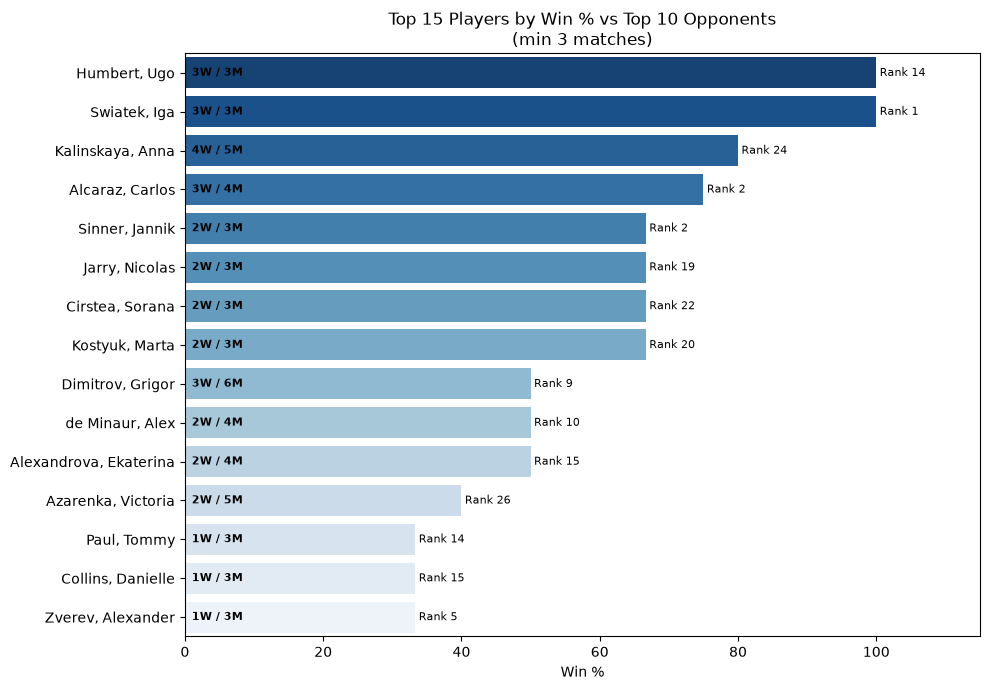

In [15]:
top15 = stats.head(15).copy()

fig, ax = plt.subplots(figsize=(10, 7))

sns.barplot(data=top15, x="Win %", y="Full Name", palette="Blues_r", ax=ax)

for i, row in top15.iterrows():
    ax.text( 1, i, f"{int(row['Wins vs Top 10'])}W / {int(row['Matches vs Top 10'])}M",
        va="center", ha="left",
        fontsize=8, color="black", fontweight="bold")

for i, row in top15.iterrows():
    ax.text( row["Win %"] + 0.5, i, f"Rank {int(row['Current Rank'])}",
        va="center", ha="left",
        fontsize=8, color="black")

ax.set_title("Top 15 Players by Win % vs Top 10 Opponents\n(min 3 matches)")
ax.set_xlabel("Win %")
ax.set_ylabel("")
ax.set_xlim(0, 115)

plt.tight_layout()
plt.show()